In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob

DATA_DIR = Path("../token_evolution_data/excerpts")
N_LAYERS = 13 # layers 0 to 12 (embedding + 12 transformer layers)
D_MODEL = 768
SEED = 123

# We load a subset of excerpts
rng = np.random.default_rng(SEED)
excerpt_files = sorted(glob.glob(str(DATA_DIR / "excerpt_*.npz")))
rng.shuffle(excerpt_files) # shuffle excerpt_files

all_hidden = [] # list of (13, seq_len, 768) arrays
total_tokens = 0
TARGET_TOKENS = 50000

for f in excerpt_files:
    data = np.load(f, allow_pickle=True)
    hs = data["hidden_states"] # (13, seq_len, 768)
    all_hidden.append(hs)
    total_tokens += hs.shape[1]
    if total_tokens >= TARGET_TOKENS: 
        break

# Concatenate along the token axis -> (13, total_tokens, 768)
hidden_pool = np.concatenate(all_hidden, axis=1)
print(f"Loaded {len(all_hidden)} excerpts, {hidden_pool.shape[1]} tokens total")
print(f"hidden_pool shape: {hidden_pool.shape}")
del all_hidden

Loaded 299 excerpts, 50126 tokens total
hidden_pool shape: (13, 50126, 768)


In [11]:
# Sample N_PAIRS random token pairs (indices into the token axis)
N_PAIRS = 10000
n_tokens = hidden_pool.shape[1]
idx_a = rng.integers(0, n_tokens, size=N_PAIRS)
idx_b = rng.integers(0, n_tokens, size=N_PAIRS)

# Ensure pairs are distinct tokens
mask = idx_a == idx_b
while mask.any():
    idx_b[mask] = rng.integers(0, n_tokens, size=mask.sum())
    mask = idx_a == idx_b
assert (idx_a != idx_b).all(), "All pairs should be distinct tokens"

# Compute cosine similarity for each (layer, pair)
# (13, N_PAIRS, 768)
h_a = hidden_pool[:, idx_a, :]
h_b = hidden_pool[:, idx_b, :]
dimwise_product = h_a * h_b

# Norms: (13, N_PAIRS)
norm_a = np.linalg.norm(h_a, axis=2)
norm_b = np.linalg.norm(h_b, axis=2)
norm_prod = norm_a * norm_b # (13, N_PAIRS)

# Cosine similarity = dot(a,b) / (||a|| ||b||)
dot_ab = dimwise_product.sum(axis=2) # (13, N_PAIRS)
cos_sim = dot_ab / norm_prod # (13, N_PAIRS)

# Mean and variance per layer (13,)
cos_mean = cos_sim.mean(axis=1)
cos_var = cos_sim.var(axis=1)

print("Layer | Mean cos sim | Variance")
print("------+--------------+---------")
for layer in range(N_LAYERS):
    print(f"  {layer:2d}  |   {cos_mean[layer]:+.6f}  | {cos_var[layer]:.6f}")

Layer | Mean cos sim | Variance
------+--------------+---------
   0  |   +0.061614  | 0.017628
   1  |   +0.263991  | 0.025470
   2  |   +0.369110  | 0.019899
   3  |   +0.353857  | 0.011073
   4  |   +0.257000  | 0.006988
   5  |   +0.314176  | 0.007191
   6  |   +0.484437  | 0.009896
   7  |   +0.470049  | 0.015468
   8  |   +0.539250  | 0.028231
   9  |   +0.548501  | 0.025024
  10  |   +0.476995  | 0.019231
  11  |   +0.483415  | 0.026900
  12  |   +0.969043  | 0.003167


In [12]:
# For each pair (a, b), cosine_sim = sum_d [ a_d * b_d ] / (||a|| * ||b||)
# The contribution of dimension d is: (a_d * b_d) / (||a|| * ||b||)
# We average this over all pairs and normalize by the mean cosine similarity.

# dimwise_contribution[layer, pair, dim] = (a_d * b_d) / (||a|| * ||b||)
dimwise_contribution = dimwise_product / norm_prod[:, :, np.newaxis]  # (13, N_PAIRS, 768)

# Expected contribution per dimension: average over pairs → (13, 768)
expected_dimwise = dimwise_contribution.mean(axis=1)  # (13, 768)

# Normalize by expected total cosine similarity (= cos_mean) so rows sum to 1
# normalized_contribution[layer, dim] = E[a_d*b_d / (||a||*||b||)] / E[cos_sim]
normalized_contribution = expected_dimwise / cos_mean[:, np.newaxis]  # (13, 768)

# Verify: each row should sum to ~1.0
row_sums = normalized_contribution.sum(axis=1)
print("Row sums (should be ~1.0):", row_sums)
print(f"\nnormalized_contribution shape: {normalized_contribution.shape}")

Row sums (should be ~1.0): [0.99999815 0.9999993  1.0000032  1.0000002  1.0000012  1.0000026
 0.9999988  1.0000001  0.99999905 0.99999833 1.         1.000001
 0.99999833]

normalized_contribution shape: (13, 768)


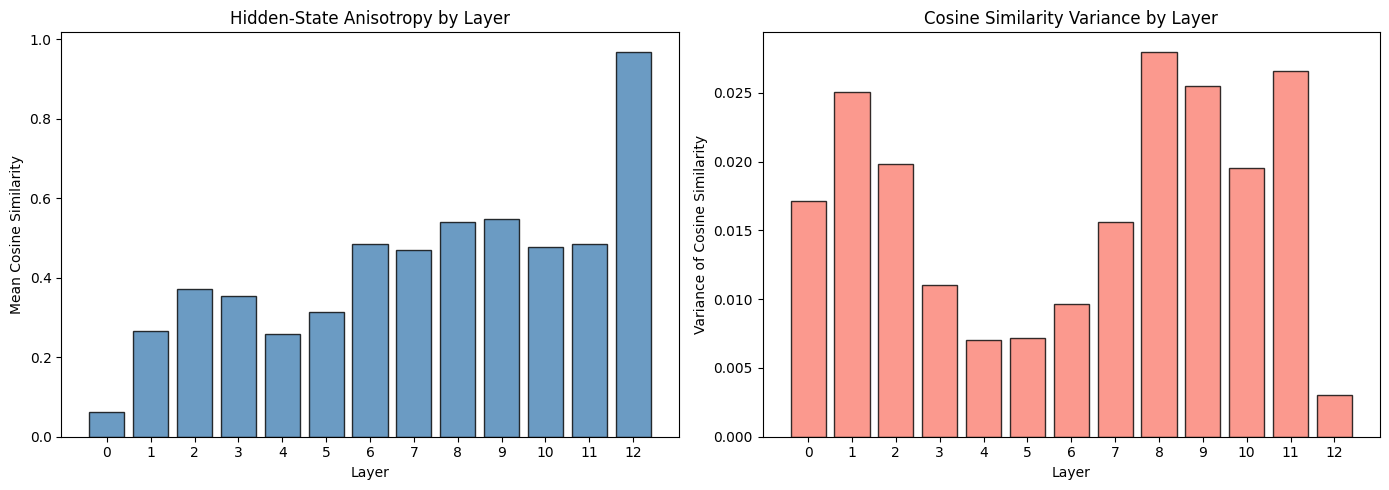

In [ ]:
# ── Plot 1: Anisotropy (mean cosine similarity) per layer ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

layers = np.arange(N_LAYERS)

ax = axes[0]
ax.bar(layers, cos_mean, color="steelblue", edgecolor="black", alpha=0.8)
ax.set_xlabel("Layer")
ax.set_ylabel("Mean Cosine Similarity")
ax.set_title("Hidden-State Anisotropy by Layer")
ax.set_xticks(layers)
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")

ax = axes[1]
ax.bar(layers, cos_var, color="salmon", edgecolor="black", alpha=0.8)
ax.set_xlabel("Layer")
ax.set_ylabel("Variance of Cosine Similarity")
ax.set_title("Cosine Similarity Variance by Layer")
ax.set_xticks(layers)

plt.tight_layout()
plt.show()

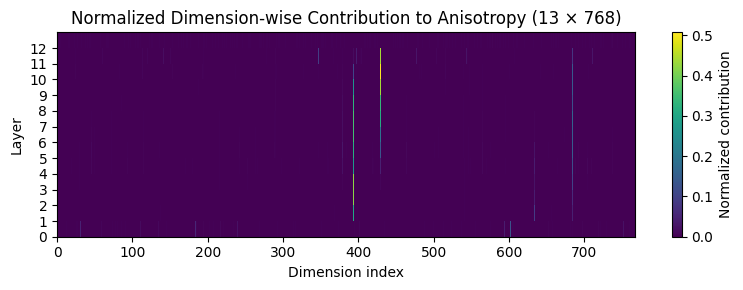

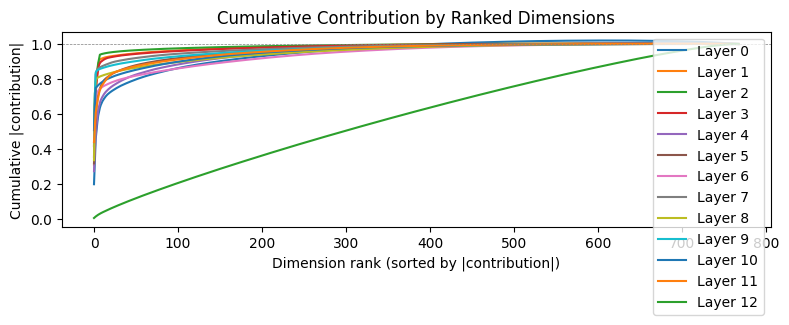

In [36]:
# ── Plot 2: Heatmap of normalized dimension-wise contributions ──────────────
fig, ax = plt.subplots(figsize=(8, 3))
im = ax.pcolormesh(normalized_contribution)
ax.set_xlabel("Dimension index")
ax.set_ylabel("Layer")
ax.set_yticks(layers)
ax.set_title("Normalized Dimension-wise Contribution to Anisotropy (13 × 768)")
plt.colorbar(im, ax=ax, label="Normalized contribution")
plt.tight_layout()
plt.show()

# ── Plot 3: Top contributing dimensions per layer ──────────────────────────
fig, ax = plt.subplots(figsize=(8, 3))
# Show sorted absolute contribution for a few selected layers
for layer_idx in range(N_LAYERS):
    sorted_contrib = np.sort(normalized_contribution[layer_idx])[::-1]
    cumulative = np.cumsum(sorted_contrib)
    ax.plot(cumulative, label=f"Layer {layer_idx}")
ax.set_xlabel("Dimension rank (sorted by |contribution|)")
ax.set_ylabel("Cumulative |contribution|")
ax.set_title("Cumulative Contribution by Ranked Dimensions")
ax.legend()
ax.axhline(1.0, color="gray", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

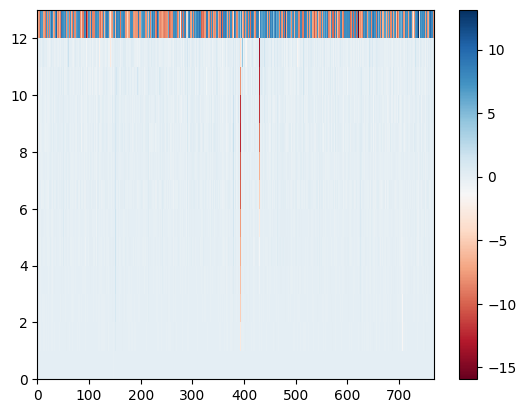

In [49]:
plt.pcolormesh(hidden_pool.mean(axis=1), cmap='RdBu')
plt.colorbar()

In [39]:
# Compute cosine similarity between layer i and layer j across all tokens
cos_sim_layerwise_full = np.full(shape=(N_LAYERS, N_LAYERS), fill_value=np.nan)

# Also do the same computation with the top k "rogue dimensions" removed,
# which refer to dimensions that dominate the average cosine similarity
# between random pairs of tokens
k = 3
rogue_dims = np.argsort(normalized_contribution.mean(axis=0))[-k:]
dims_to_use = np.setdiff1d(np.arange(D_MODEL), rogue_dims)
cos_sim_layerwise_rogue_removed = np.full(shape=(N_LAYERS, N_LAYERS), fill_value=np.nan)

for i in range(N_LAYERS):
    for j in range(i, N_LAYERS):
        print("Computing cosine similarity between layer", i, "and layer", j)
        h_i = hidden_pool[i, :, :]
        h_j = hidden_pool[j, :, :]
        dot_ij = (h_i * h_j).sum(axis=1)
        norm_i = np.linalg.norm(h_i, axis=1) # (total_tokens,)
        norm_j = np.linalg.norm(h_j, axis=1) # (total_tokens,)
        cos_sim_layerwise_full[i, j] = (dot_ij / (norm_i * norm_j)).mean()

        h_i = h_i[:, dims_to_use]
        h_j = h_j[:, dims_to_use]
        dot_ij = (h_i * h_j).sum(axis=1)
        norm_i = np.linalg.norm(h_i, axis=1) # (total_tokens,)
        norm_j = np.linalg.norm(h_j, axis=1) # (total_tokens,)
        cos_sim_layerwise_rogue_removed[i, j] = (dot_ij / (norm_i * norm_j)).mean()

Computing cosine similarity between layer 0 and layer 0
Computing cosine similarity between layer 0 and layer 1
Computing cosine similarity between layer 0 and layer 2
Computing cosine similarity between layer 0 and layer 3
Computing cosine similarity between layer 0 and layer 4
Computing cosine similarity between layer 0 and layer 5
Computing cosine similarity between layer 0 and layer 6
Computing cosine similarity between layer 0 and layer 7
Computing cosine similarity between layer 0 and layer 8
Computing cosine similarity between layer 0 and layer 9
Computing cosine similarity between layer 0 and layer 10
Computing cosine similarity between layer 0 and layer 11
Computing cosine similarity between layer 0 and layer 12
Computing cosine similarity between layer 1 and layer 1
Computing cosine similarity between layer 1 and layer 2
Computing cosine similarity between layer 1 and layer 3
Computing cosine similarity between layer 1 and layer 4
Computing cosine similarity between layer 1 a

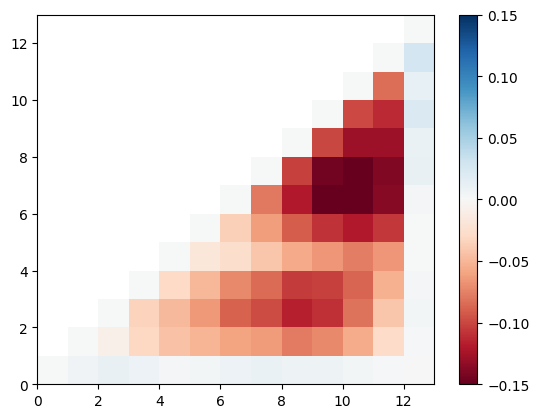

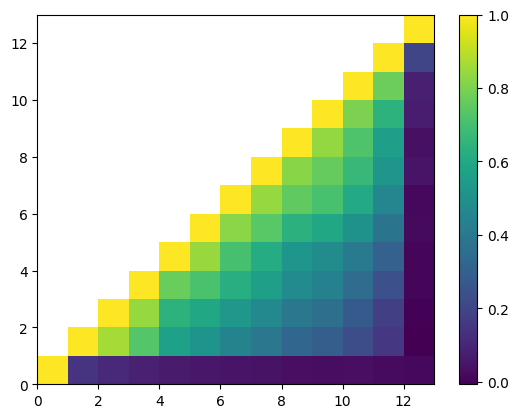

In [46]:
plt.pcolormesh(cos_sim_layerwise_rogue_removed - cos_sim_layerwise_full, vmin=-0.15, vmax=0.15, cmap="RdBu")
plt.colorbar()
plt.show()
plt.pcolormesh(cos_sim_layerwise_full)
plt.colorbar()

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "EleutherAI/pythia-160m-deduped"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1050.81it/s, Materializing param=gpt_neox.layers.11.post_attention_layernorm.weight]


In [64]:
torch.tensor(hidden_pool[-1, 0, :], dtype=torch.float32)

tensor([ -9.8828,   5.4688,  -5.3633, -10.2969,  -9.7656,   6.6250,   9.0859,
         -6.2227,   8.8672,   8.4609,  -9.2812, -10.8281,   9.3438,  -5.9609,
         -8.8984, -10.0156, -10.0234,   7.2109,   7.4961,  -8.2578,   9.1484,
          5.4023,  -7.4883,  -6.8320,   4.3281,   5.2617,  -7.4297,   7.9219,
         -8.5391,   6.3438,  -8.7109,  -5.5078, -10.2188,  -8.1484,  -8.0312,
          7.6953,   6.7500,   8.2344,   5.5664,  -7.8125,  -9.9141,  -6.2266,
         -5.7734,  -8.6484,  -7.7227,  10.4922,   9.3594,   9.7031,   8.5625,
         10.7656,   6.3789, -11.1250,   6.8086,  -7.4219,   8.3594,  -7.3281,
         -8.1406, -11.7031,   7.2773,  -7.4961,   2.4766,   7.2422,  -9.8594,
          8.6094,   8.0625,   8.7344,  -8.3438,   8.2734,  -9.5000,  10.9922,
          9.7812,  -9.1406,   6.1602,  -6.3398,   6.9102,   4.5352,  -7.9922,
          5.4766,   7.0117,   7.5039,  -5.2773,   8.2578,   7.7617,  -8.4375,
          7.7500,  -4.5938,  -7.2695,  -8.4062,   7.6328, -10.91

In [58]:
import torch
model.gpt_neox.final_layer_norm(torch.tensor(hidden_pool[-1, 0, :], dtype=torch.float32))

RuntimeError: mixed dtype (CPU): expect parameter to have scalar type of Float